In [1]:
#Membaca dan memuat dataset
import pandas as pd
df = pd.read_csv('berita_kompas_raw.csv')
df

,Judul,Kategori,Link,Tanggal
0,"Babak Baru ""Drama"" Bupati Gowa: Pemakzulan Dis...",Nasional,https://nasional.kompas.com/read/2026/10/04/11...,4 Oktober 2026
1,"Viral Video Keributan Remaja di Jalan Samas, P...",Yogyakarta,https://yogyakarta.kompas.com/read/2026/10/04/...,4 Oktober 2026
2,"Wanita di Sambas Ditemukan Tewas di Kamar, Did...",Regional,https://regional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
3,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,Megapolitan,https://megapolitan.kompas.com/read/2026/10/04...,4 Oktober 2026
4,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,Nasional,https://nasional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
...,...,...,...,...
133,Kalapas Perempuan Bandung Jelaskan soal Wacana...,Bandung,https://bandung.kompas.com/read/2026/10/03/183...,3 Oktober 2026
134,"Eskalator Stasiun Duri Mendadak Mundur, Penump...",Megapolitan,https://megapolitan.kompas.com/read/2026/10/03...,3 Oktober 2026
135,Polisi Gianyar Diduga Jual Senpi Ilegal Rp 30 ...,Denpasar,https://denpasar.kompas.com/read/2026/10/03/18...,3 Oktober 2026
136,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...",Nasional,https://nasional.kompas.com/read/2026/10/03/18...,3 Oktober 2026


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Judul     138 non-null    str  
 1   Kategori  128 non-null    str  
 2   Link      138 non-null    str  
 3   Tanggal   101 non-null    str  
dtypes: str(4)
memory usage: 4.4 KB


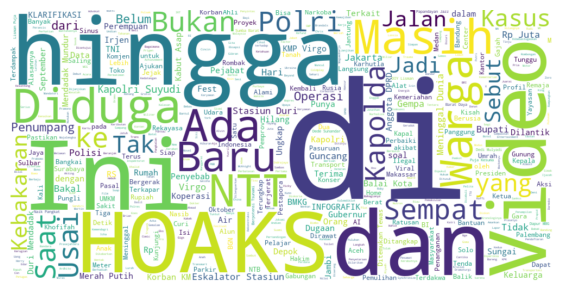

In [3]:
#Visualisasi wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['Judul'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=500).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [4]:
#Remove HTML
import re
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

df['rm_html'] = df['Judul'].apply(remove_html)
df[['Judul','rm_html']]

,Judul,rm_html
0,"Babak Baru ""Drama"" Bupati Gowa: Pemakzulan Dis...","Babak Baru ""Drama"" Bupati Gowa: Pemakzulan Dis..."
1,"Viral Video Keributan Remaja di Jalan Samas, P...","Viral Video Keributan Remaja di Jalan Samas, P..."
2,"Wanita di Sambas Ditemukan Tewas di Kamar, Did...","Wanita di Sambas Ditemukan Tewas di Kamar, Did..."
3,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 Pria Diduga Mesum di Toilet Stasiun Manggara...
4,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...
...,...,...
133,Kalapas Perempuan Bandung Jelaskan soal Wacana...,Kalapas Perempuan Bandung Jelaskan soal Wacana...
134,"Eskalator Stasiun Duri Mendadak Mundur, Penump...","Eskalator Stasiun Duri Mendadak Mundur, Penump..."
135,Polisi Gianyar Diduga Jual Senpi Ilegal Rp 30 ...,Polisi Gianyar Diduga Jual Senpi Ilegal Rp 30 ...
136,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...","BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora..."


In [5]:
#Remove Hashtag
def remove_hashtag(text):
    return re.sub(r'#\w+', '', text)

df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df[['rm_html','rm_hashtag']]

,rm_html,rm_hashtag
0,"Babak Baru ""Drama"" Bupati Gowa: Pemakzulan Dis...","Babak Baru ""Drama"" Bupati Gowa: Pemakzulan Dis..."
1,"Viral Video Keributan Remaja di Jalan Samas, P...","Viral Video Keributan Remaja di Jalan Samas, P..."
2,"Wanita di Sambas Ditemukan Tewas di Kamar, Did...","Wanita di Sambas Ditemukan Tewas di Kamar, Did..."
3,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 Pria Diduga Mesum di Toilet Stasiun Manggara...
4,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...
...,...,...
133,Kalapas Perempuan Bandung Jelaskan soal Wacana...,Kalapas Perempuan Bandung Jelaskan soal Wacana...
134,"Eskalator Stasiun Duri Mendadak Mundur, Penump...","Eskalator Stasiun Duri Mendadak Mundur, Penump..."
135,Polisi Gianyar Diduga Jual Senpi Ilegal Rp 30 ...,Polisi Gianyar Diduga Jual Senpi Ilegal Rp 30 ...
136,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...","BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora..."


In [6]:
#Lower Casing
df['lower_case'] = df['rm_hashtag'].str.lower()
df[['rm_hashtag', 'lower_case']]

,rm_hashtag,lower_case
0,"Babak Baru ""Drama"" Bupati Gowa: Pemakzulan Dis...","babak baru ""drama"" bupati gowa: pemakzulan dis..."
1,"Viral Video Keributan Remaja di Jalan Samas, P...","viral video keributan remaja di jalan samas, p..."
2,"Wanita di Sambas Ditemukan Tewas di Kamar, Did...","wanita di sambas ditemukan tewas di kamar, did..."
3,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 pria diduga mesum di toilet stasiun manggara...
4,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
...,...,...
133,Kalapas Perempuan Bandung Jelaskan soal Wacana...,kalapas perempuan bandung jelaskan soal wacana...
134,"Eskalator Stasiun Duri Mendadak Mundur, Penump...","eskalator stasiun duri mendadak mundur, penump..."
135,Polisi Gianyar Diduga Jual Senpi Ilegal Rp 30 ...,polisi gianyar diduga jual senpi ilegal rp 30 ...
136,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...","bgn bakal ""cut off"" yayasan yang pungut setora..."


In [7]:
#Remove URL
import re
def remove_rls(text):
    text = re.sub(r'https?\/\/S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'http\S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'www\S+', '',  str(text)) # remove the www
    text = re.sub(r'\S+@\S+', '', str(text)) # remove the email
    return text

df['rm_url'] = df['lower_case'].apply(remove_rls)
df[['lower_case','rm_url']]

,lower_case,rm_url
0,"babak baru ""drama"" bupati gowa: pemakzulan dis...","babak baru ""drama"" bupati gowa: pemakzulan dis..."
1,"viral video keributan remaja di jalan samas, p...","viral video keributan remaja di jalan samas, p..."
2,"wanita di sambas ditemukan tewas di kamar, did...","wanita di sambas ditemukan tewas di kamar, did..."
3,2 pria diduga mesum di toilet stasiun manggara...,2 pria diduga mesum di toilet stasiun manggara...
4,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
...,...,...
133,kalapas perempuan bandung jelaskan soal wacana...,kalapas perempuan bandung jelaskan soal wacana...
134,"eskalator stasiun duri mendadak mundur, penump...","eskalator stasiun duri mendadak mundur, penump..."
135,polisi gianyar diduga jual senpi ilegal rp 30 ...,polisi gianyar diduga jual senpi ilegal rp 30 ...
136,"bgn bakal ""cut off"" yayasan yang pungut setora...","bgn bakal ""cut off"" yayasan yang pungut setora..."


In [8]:
#Remove Punctuations
import string
punc = string.punctuation + '"“”‘’'
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', punc))

df['rm_punc'] = df['rm_url'].apply(remove_punctuation)
df[['rm_url','rm_punc']]

,rm_url,rm_punc
0,"babak baru ""drama"" bupati gowa: pemakzulan dis...",babak baru drama bupati gowa pemakzulan disetu...
1,"viral video keributan remaja di jalan samas, p...",viral video keributan remaja di jalan samas po...
2,"wanita di sambas ditemukan tewas di kamar, did...",wanita di sambas ditemukan tewas di kamar didu...
3,2 pria diduga mesum di toilet stasiun manggara...,2 pria diduga mesum di toilet stasiun manggara...
4,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
...,...,...
133,kalapas perempuan bandung jelaskan soal wacana...,kalapas perempuan bandung jelaskan soal wacana...
134,"eskalator stasiun duri mendadak mundur, penump...",eskalator stasiun duri mendadak mundur penumpa...
135,polisi gianyar diduga jual senpi ilegal rp 30 ...,polisi gianyar diduga jual senpi ilegal rp 30 ...
136,"bgn bakal ""cut off"" yayasan yang pungut setora...",bgn bakal cut off yayasan yang pungut setoran ...


In [9]:
from mpstemmer import MPStemmer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stemmer = MPStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
#Stemmer
df['stem'] = df['rm_punc'].apply(lambda x: stemmer.stem_kalimat(x) if isinstance(x, str) else '')
df[['rm_punc','stem']]

,rm_punc,stem
0,babak baru drama bupati gowa pemakzulan disetu...,babak baru drama bupati gowa makzul tuju ma ke...
1,viral video keributan remaja di jalan samas po...,viral video ribut remaja di jalan samas polres...
2,wanita di sambas ditemukan tewas di kamar didu...,wanita di sambas temu tewas di kamar duga tusu...
3,2 pria diduga mesum di toilet stasiun manggara...,2 pria duga mesum di toilet stasiun manggarai ...
4,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
...,...,...
133,kalapas perempuan bandung jelaskan soal wacana...,kalapas perempuan bandung jelas soal wacana bi...
134,eskalator stasiun duri mendadak mundur penumpa...,eskalator stasiun duri dadak mundur tumpang sa...
135,polisi gianyar diduga jual senpi ilegal rp 30 ...,polisi gianyar duga jual senpi ilegal rp 30 ju...
136,bgn bakal cut off yayasan yang pungut setoran ...,bgn bakal cut off yayasan yang pungut setor ke...


In [11]:
#Remove Stopword
sw = set(stopwords.words('indonesian'))
def remove_stopwords(text):
  return " ".join([word for word in str(text).split() if word not in sw])
df['rm_stopwords'] = df['stem'].apply(remove_stopwords)
df[['stem','rm_stopwords']]

,stem,rm_stopwords
0,babak baru drama bupati gowa makzul tuju ma ke...,babak drama bupati gowa makzul tuju ma kemenda...
1,viral video ribut remaja di jalan samas polres...,viral video ribut remaja jalan samas polres ba...
2,wanita di sambas temu tewas di kamar duga tusu...,wanita sambas temu tewas kamar duga tusuk suami
3,2 pria duga mesum di toilet stasiun manggarai ...,2 pria duga mesum toilet stasiun manggarai tan...
4,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
...,...,...
133,kalapas perempuan bandung jelas soal wacana bi...,kalapas perempuan bandung wacana bilik keluarg...
134,eskalator stasiun duri dadak mundur tumpang sa...,eskalator stasiun duri dadak mundur tumpang be...
135,polisi gianyar duga jual senpi ilegal rp 30 ju...,polisi gianyar duga jual senpi ilegal rp 30 ju...
136,bgn bakal cut off yayasan yang pungut setor ke...,bgn cut off yayasan pungut setor mitra dapur mbg


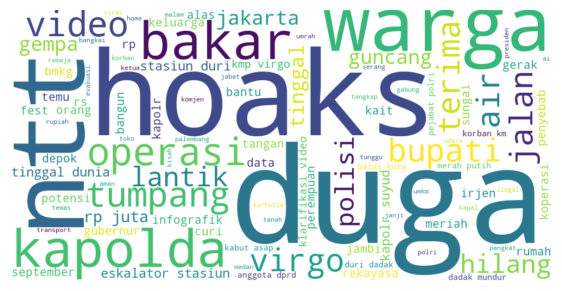

In [12]:
#Visualisasi Wordcloud setelah Preprocessing
text = ' '.join(df['rm_stopwords'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [13]:
#Rename Kolom
df.rename(columns={'rm_stopwords': 'Prepro'}, inplace=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Judul       138 non-null    str  
 1   Kategori    128 non-null    str  
 2   Link        138 non-null    str  
 3   Tanggal     101 non-null    str  
 4   rm_html     138 non-null    str  
 5   rm_hashtag  138 non-null    str  
 6   lower_case  138 non-null    str  
 7   rm_url      138 non-null    str  
 8   rm_punc     138 non-null    str  
 9   stem        138 non-null    str  
 10  Prepro      138 non-null    str  
dtypes: str(11)
memory usage: 12.0 KB


In [15]:
df[['Judul','Prepro','Kategori','Link','Tanggal']]

,Judul,Prepro,Kategori,Link,Tanggal
0,"Babak Baru ""Drama"" Bupati Gowa: Pemakzulan Dis...",babak drama bupati gowa makzul tuju ma kemenda...,Nasional,https://nasional.kompas.com/read/2026/10/04/11...,4 Oktober 2026
1,"Viral Video Keributan Remaja di Jalan Samas, P...",viral video ribut remaja jalan samas polres ba...,Yogyakarta,https://yogyakarta.kompas.com/read/2026/10/04/...,4 Oktober 2026
2,"Wanita di Sambas Ditemukan Tewas di Kamar, Did...",wanita sambas temu tewas kamar duga tusuk suami,Regional,https://regional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
3,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 pria duga mesum toilet stasiun manggarai tan...,Megapolitan,https://megapolitan.kompas.com/read/2026/10/04...,4 Oktober 2026
4,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...,Nasional,https://nasional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
...,...,...,...,...,...
133,Kalapas Perempuan Bandung Jelaskan soal Wacana...,kalapas perempuan bandung wacana bilik keluarg...,Bandung,https://bandung.kompas.com/read/2026/10/03/183...,3 Oktober 2026
134,"Eskalator Stasiun Duri Mendadak Mundur, Penump...",eskalator stasiun duri dadak mundur tumpang be...,Megapolitan,https://megapolitan.kompas.com/read/2026/10/03...,3 Oktober 2026
135,Polisi Gianyar Diduga Jual Senpi Ilegal Rp 30 ...,polisi gianyar duga jual senpi ilegal rp 30 ju...,Denpasar,https://denpasar.kompas.com/read/2026/10/03/18...,3 Oktober 2026
136,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...",bgn cut off yayasan pungut setor mitra dapur mbg,Nasional,https://nasional.kompas.com/read/2026/10/03/18...,3 Oktober 2026


In [16]:
#Download csv hasil Pre-Processing
df[['Judul','Prepro','Kategori','Link','Tanggal']].to_csv('berita_kompas_prepro.csv', index=False)